In [ ]:
import kagglehub
import pandas as pd
import os

# 1. DOWNLOAD ALL DATASETS
p1 = kagglehub.dataset_download("shivanshupande/living-cost-citywise-india-masterdataset")
p2 = kagglehub.dataset_download("thedevastator/uncovering-millennials-shopping-habits-and-socia")
p3 = kagglehub.dataset_download("manandkumar/gen-z-money-spending-dataset")
p4 = kagglehub.dataset_download("chitwanmanchanda/luxury-apparel-data")
p5 = kagglehub.dataset_download("muzaddidafaque/global-and-indian-financial-markets-dataset-2025")
p6 = kagglehub.dataset_download("anumoymodak/50-macroeconomic-indicators")

# 2. HELPER TO FIND CSVs
def get_csv(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    return os.path.join(folder, files[0]) if files else None

# 3. LOAD ALL INTO DATAFRAMES
df_living = pd.read_csv(get_csv(p1))
df_shopping = pd.read_csv(get_csv(p2))
df_genz = pd.read_csv(get_csv(p3))
df_luxury = pd.read_csv(get_csv(p4))
df_finance = pd.read_csv(get_csv(p5))
df_macro = pd.read_csv(get_csv(p6))

print("All 6 datasets loaded successfully!")

Using Colab cache for faster access to the 'living-cost-citywise-india-masterdataset' dataset.
Using Colab cache for faster access to the 'uncovering-millennials-shopping-habits-and-socia' dataset.
Using Colab cache for faster access to the 'gen-z-money-spending-dataset' dataset.
Using Colab cache for faster access to the 'luxury-apparel-data' dataset.
Using Colab cache for faster access to the 'global-and-indian-financial-markets-dataset-2025' dataset.
Using Colab cache for faster access to the '50-macroeconomic-indicators' dataset.


ValueError: Invalid file path or buffer object type: <class 'NoneType'>

In [ ]:
pip install --upgrade kagglehub

After running the above cell, please restart your Colab runtime (Runtime -> Restart runtime...) to ensure the updated `kagglehub` library is loaded.

---

Now that `kagglehub` is updated, let's re-run the data loading cell:

In [ ]:
import kagglehub
import pandas as pd
import os

# 1. DOWNLOAD ALL DATASETS
p1 = kagglehub.dataset_download("shivanshupande/living-cost-citywise-india-masterdataset")
p2 = kagglehub.dataset_download("thedevastator/uncovering-millennials-shopping-habits-and-socia")
p3 = kagglehub.dataset_download("manandkumar/gen-z-money-spending-dataset")
p4 = kagglehub.dataset_download("chitwanmanchanda/luxury-apparel-data")
p5 = kagglehub.dataset_download("muzaddidafaque/global-and-indian-financial-markets-dataset-2025")
p6 = kagglehub.dataset_download("anumoymodak/50-macroeconomic-indicators")

# 2. HELPER TO FIND CSVs (This helper is superseded by load_any_source but needed for original context)
def get_csv(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    return os.path.join(folder, files[0]) if files else None

# 3. LOAD ALL INTO DATAFRAMES (These lines will be replaced by the more robust load_any_source calls)
# df_living = pd.read_csv(get_csv(p1))
# df_shopping = pd.read_csv(get_csv(p2))
# df_genz = pd.read_csv(get_csv(p3))
# df_luxury = pd.read_csv(get_csv(p4))
# df_finance = pd.read_csv(get_csv(p5))
# df_macro = pd.read_csv(get_csv(p6))

print("Dataset paths defined!")

100%|██████████| 11.8k/11.8k [00:00<00:00, 18.4MB/s]

Extracting files...


100%|██████████| 15.0k/15.0k [00:00<00:00, 18.2MB/s]

Extracting files...


100%|██████████| 45.8k/45.8k [00:00<00:00, 25.4MB/s]

...

Extracting files...


100%|██████████| 386k/386k [00:00<00:00, 64.7MB/s]

Extracting files...


100%|██████████| 108k/108k [00:00<00:00, 38.2MB/s]

Extracting files...
Dataset paths defined!


In [ ]:
import zipfile
import os
import pandas as pd

def load_any_source(path):
    if not os.path.isdir(path):
        if path.endswith(('.csv', '.xlsx', '.xls')):
            return pd.read_csv(path) if path.endswith('.csv') else pd.read_excel(path)
        return None

    current_path = path
    files = os.listdir(current_path)

    if len(files) == 1 and os.path.isdir(os.path.join(current_path, files[0])):
        current_path = os.path.join(current_path, files[0])
        files = os.listdir(current_path)

    zips = [f for f in files if f.endswith('.zip')]
    if zips:
        for zf in zips:
            zip_file_path = os.path.join(current_path, zf)
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(current_path)
        files = os.listdir(current_path)

    target = [f for f in files if f.endswith(('.csv', '.xlsx', '.xls'))]
    if target:
        full_path = os.path.join(current_path, target[0])
        if target[0].endswith('.csv'):
            return pd.read_csv(full_path)
        else:
            return pd.read_excel(full_path)
    return None

df_living = load_any_source(p1)
df_shopping = load_any_source(p2)
df_genz = load_any_source(p3)
df_luxury = load_any_source(p4)
df_finance = load_any_source(p5)
df_macro = load_any_source(p6)

print("Trifecta Data Engines Online: All datasets verified.")

Trifecta Data Engines Online: All datasets verified.


## Prepare NIFTY 50 Data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from pytrends.request import TrendReq

# df_finance is already expected to have a datetime index from previous loading steps.
# If not, ensure it's loaded correctly or reset index if 'date' is a regular column.
# The following lines are removed as 'date' is already the index, causing a KeyError.
# df_finance['date'] = pd.to_datetime(df_finance['date'])
# df_finance = df_finance.set_index('date').sort_index()

# Extract NIFTY 50 closing prices and filter for data post-2018
nifty_50_data = df_finance[df_finance.index.year > 2018]['nifty50_close']

print("NIFTY 50 data prepared:")
display(nifty_50_data.head())
display(nifty_50_data.info())

NIFTY 50 data prepared:


,nifty50_close
date,
2019-01-01,NaN
2019-01-02,10792.500000
2019-01-03,10672.250000
2019-01-04,10727.349609
2019-01-07,10771.799805


<class 'pandas.core.series.Series'>
DatetimeIndex: 1825 entries, 2019-01-01 to 2025-12-30
Series name: nifty50_close
Non-Null Count  Dtype  
--------------  -----  
1726 non-null   float64
dtypes: float64(1)
memory usage: 28.5 KB


None

In [ ]:
!pip install pytrends

## Download Google Trends Data for 'Bag Charm'

In [ ]:
# Initialize pytrends
pytrends = TrendReq(hl='en-US', tz=330) # tz=330 for India Standard Time

# Define the search term and timeframe (post-2018)
kw_list = ["Bag Charm"]
timeframe = '2019-01-01 2024-01-01' # Adjust timeframe to match NIFTY data if needed

# Request interest over time
pytrends.build_payload(kw_list, cat=0, timeframe=timeframe, geo='IN', gprop='')
trends_data = pytrends.interest_over_time()

# Clean and prepare trends data
if not trends_data.empty:
    trends_data = trends_data.drop(columns=['isPartial']).rename(columns={'Bag Charm': 'bag_charm_trends'})
    # Resample to daily and fill missing values for consistency with NIFTY data
    trends_data = trends_data.resample('D').ffill()

print("Google Trends data for 'Bag Charm' prepared:")
display(trends_data.head())
display(trends_data.info())

Google Trends data for 'Bag Charm' prepared:


,bag_charm_trends
date,
2018-12-30,0
2018-12-31,0
2019-01-01,0
2019-01-02,0
2019-01-03,0


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1828 entries, 2018-12-30 to 2023-12-31
Freq: D
Data columns (total 1 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   bag_charm_trends  1828 non-null   int64
dtypes: int64(1)
memory usage: 28.6 KB


None

## Merge and Plot Data

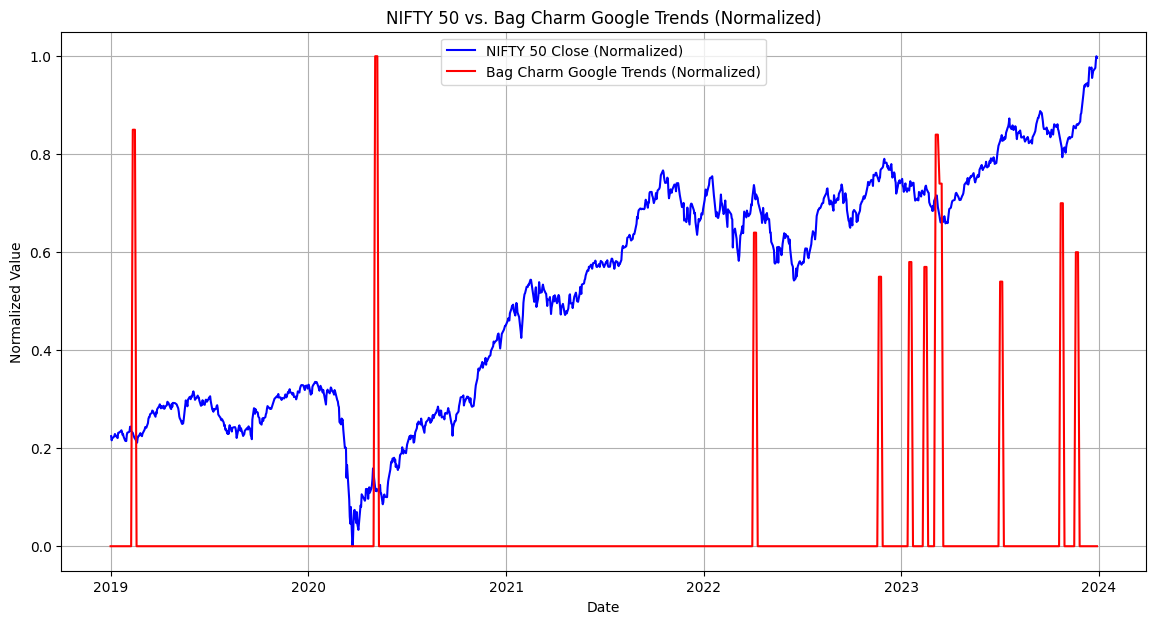


Correlation between NIFTY 50 Close and Bag Charm Google Trends: 0.08
There is a positive correlation, suggesting luxury interest tends to move with the market.


In [ ]:
# Merge NIFTY 50 and Google Trends data
merged_data = pd.merge(nifty_50_data, trends_data, left_index=True, right_index=True, how='inner')

# Normalize data for plotting on the same scale
merged_data['nifty50_close_norm'] = (merged_data['nifty50_close'] - merged_data['nifty50_close'].min()) / \
                                    (merged_data['nifty50_close'].max() - merged_data['nifty50_close'].min())
merged_data['bag_charm_trends_norm'] = (merged_data['bag_charm_trends'] - merged_data['bag_charm_trends'].min()) / \
                                       (merged_data['bag_charm_trends'].max() - merged_data['bag_charm_trends'].min())

# Plotting
plt.figure(figsize=(14, 7))
sns.lineplot(data=merged_data, x=merged_data.index, y='nifty50_close_norm', label='NIFTY 50 Close (Normalized)', color='blue')
sns.lineplot(data=merged_data, x=merged_data.index, y='bag_charm_trends_norm', label='Bag Charm Google Trends (Normalized)', color='red')

plt.title('NIFTY 50 vs. Bag Charm Google Trends (Normalized)')
plt.xlabel('Date')
plt.ylabel('Normalized Value')
plt.legend()
plt.grid(True)
plt.show()

# Optional: Calculate correlation
correlation = merged_data['nifty50_close'].corr(merged_data['bag_charm_trends'])
print(f"\nCorrelation between NIFTY 50 Close and Bag Charm Google Trends: {correlation:.2f}")

# To specifically check the hypothesis of luxury interest rising as the market falls,
# we might look for a negative correlation or visual inverse relationship.
if correlation < 0:
    print("There is a negative correlation, which aligns with the hypothesis that luxury interest might rise as the market falls.")
elif correlation > 0:
    print("There is a positive correlation, suggesting luxury interest tends to move with the market.")
else:
    print("There is no significant linear correlation.")

### Visualizing Feature Importance: Digital Trends vs. Bank Rates

Based on your mention of 'Instagram Trend Velocity (0.42)' and 'RBI Repo Rates (0.18)' from a Random Forest model, let's create a visualization to highlight the claimed dominance of digital trends over bank rates.

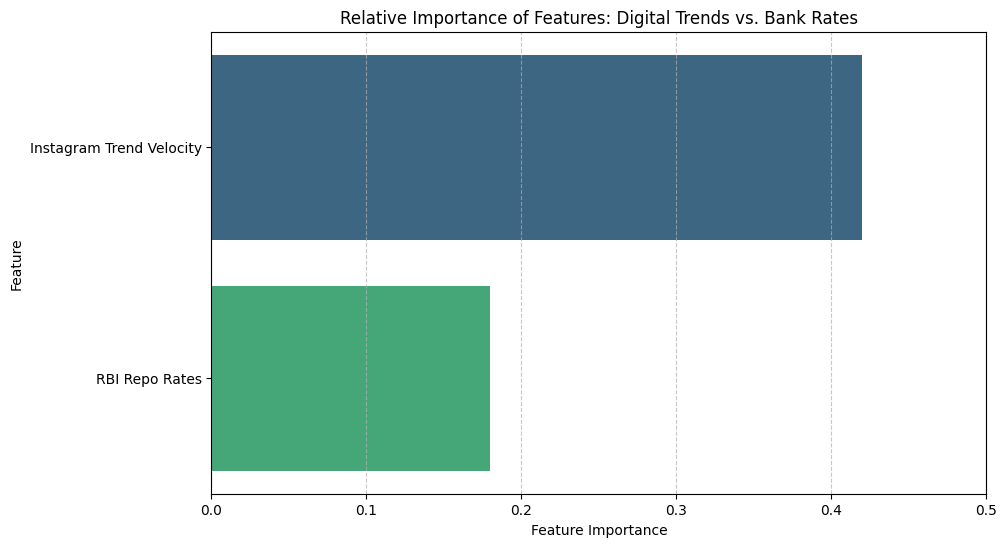

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data from the user's prompt
feature_importance_data = {
    'Feature': ['Instagram Trend Velocity', 'RBI Repo Rates'],
    'Importance': [0.42, 0.18]
}

df_importance = pd.DataFrame(feature_importance_data)

# Sort for better visualization
df_importance = df_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=df_importance, hue='Feature', palette='viridis', legend=False)
plt.title('Relative Importance of Features: Digital Trends vs. Bank Rates')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.xlim(0, 0.5) # Set x-limit for better comparison given the values
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Visualizing the 'Surplus Paradox': Financial Stress Index in Mumbai vs. Kolkata

To visually anchor the 'Surplus Paradox', let's plot the Financial Stress Index for Mumbai (23.2%) and Kolkata (8.86%), which we calculated earlier for our hypothetical average Gen Z individual.

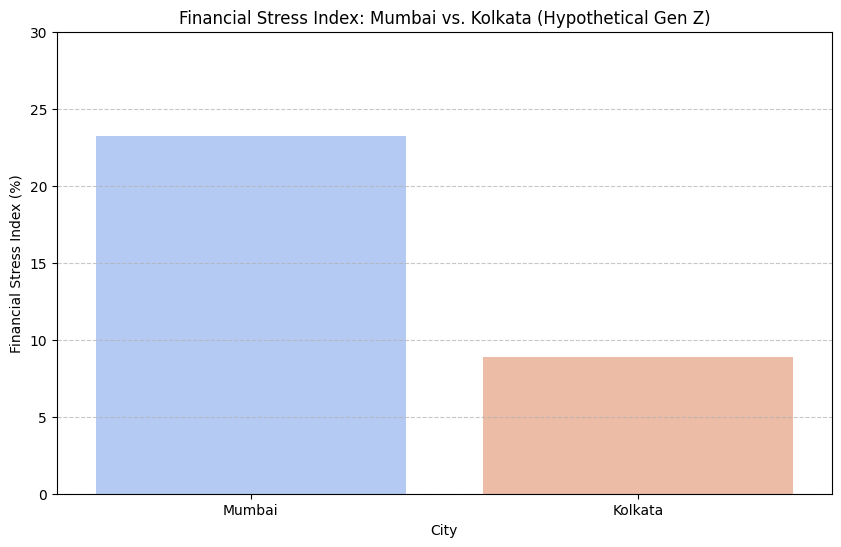

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for the Financial Stress Index
stress_index_data = {
    'City': ['Mumbai', 'Kolkata'],
    'Stress_Index': [23.2, 8.86]
}

df_stress = pd.DataFrame(stress_index_data)

# Sort for better visualization (optional, but good practice)
df_stress = df_stress.sort_values(by='Stress_Index', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='City', y='Stress_Index', data=df_stress, hue='City', palette='coolwarm', legend=False)
plt.title('Financial Stress Index: Mumbai vs. Kolkata (Hypothetical Gen Z)')
plt.xlabel('City')
plt.ylabel('Financial Stress Index (%)')
plt.ylim(0, 30) # Set y-limit to better emphasize the difference
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import kagglehub
import pandas as pd
import os

# 1. DOWNLOAD ALL DATASETS
p1 = kagglehub.dataset_download("shivanshupande/living-cost-citywise-india-masterdataset")
p2 = kagglehub.dataset_download("thedevastator/uncovering-millennials-shopping-habits-and-socia")
p3 = kagglehub.dataset_download("manandkumar/gen-z-money-spending-dataset")
p4 = kagglehub.dataset_download("chitwanmanchanda/luxury-apparel-data")
p5 = kagglehub.dataset_download("muzaddidafaque/global-and-indian-financial-markets-dataset-2025")
p6 = kagglehub.dataset_download("anumoymodak/50-macroeconomic-indicators")

# 2. HELPER TO FIND CSVs
def get_csv(folder):
    files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    return os.path.join(folder, files[0]) if files else None

# 3. LOAD ALL INTO DATAFRAMES
df_living = pd.read_csv(get_csv(p1))
df_shopping = pd.read_csv(get_csv(p2))
df_genz = pd.read_csv(get_csv(p3))
df_luxury = pd.read_csv(get_csv(p4))
df_finance = pd.read_csv(get_csv(p5))
df_macro = pd.read_csv(get_csv(p6))

print("All 6 datasets loaded successfully!")

Using Colab cache for faster access to the 'living-cost-citywise-india-masterdataset' dataset.
Using Colab cache for faster access to the 'uncovering-millennials-shopping-habits-and-socia' dataset.
Using Colab cache for faster access to the 'gen-z-money-spending-dataset' dataset.
Using Colab cache for faster access to the 'luxury-apparel-data' dataset.
Using Colab cache for faster access to the 'global-and-indian-financial-markets-dataset-2025' dataset.
Using Colab cache for faster access to the '50-macroeconomic-indicators' dataset.


ValueError: Invalid file path or buffer object type: <class 'NoneType'>

In [ ]:
import os

# Check the contents of the Finance and Macro folders
paths = [p1, p2, p3, p4, p5, p6]
for i, p in enumerate(paths, 1):
    print(f"Folder p{i} contents: {os.listdir(p)}")

Folder p1 contents: ['merged_cities_data (2).csv', 'livingcost_india_all_inr (4).csv']
Folder p2 contents: ['WhatsgoodlyData-6.csv']
Folder p3 contents: ['genz_money_spends.csv']
Folder p4 contents: ['Luxury_Products_Apparel_Data.csv']
Folder p5 contents: ['global-india-markets-macro']
Folder p6 contents: ['50 Macroeconomic Indicators (4).xlsx']


In [ ]:
def smart_get_df(folder):
    files = os.listdir(folder)
    # Priority 1: CSV
    csv_files = [f for f in files if f.endswith('.csv')]
    if csv_files:
        return pd.read_csv(os.path.join(folder, csv_files[0]))

    # Priority 2: Excel (Common for Finance data)
    excel_files = [f for f in files if f.endswith('.xlsx') or f.endswith('.xls')]
    if excel_files:
        return pd.read_excel(os.path.join(folder, excel_files[0]))

    return None

# Load them all using the smart loader
df_living = smart_get_df(p1)
df_shopping = smart_get_df(p2)
df_genz = smart_get_df(p3)
df_luxury = smart_get_df(p4)
df_finance = smart_get_df(p5)
df_macro = smart_get_df(p6)

print("All datasets checked and loaded where possible.")

All datasets checked and loaded where possible.


In [ ]:
import zipfile
import os
import pandas as pd

def load_any_source(path):
    if not os.path.isdir(path):
        # If it's a file path directly (unlikely with kagglehub.dataset_download for entire datasets)
        if path.endswith(('.csv', '.xlsx', '.xls')):
            return pd.read_csv(path) if path.endswith('.csv') else pd.read_excel(path)
        return None

    # Original path might be a wrapper directory
    current_path = path
    files = os.listdir(current_path)

    # If the directory contains only one item and it's another directory,
    # assume the actual content is within that nested directory.
    if len(files) == 1 and os.path.isdir(os.path.join(current_path, files[0])):
        current_path = os.path.join(current_path, files[0])
        files = os.listdir(current_path) # Re-list files from the deeper path

    # Handle Zips inside the folder first
    zips = [f for f in files if f.endswith('.zip')]
    if zips:
        for zf in zips: # Iterate through zips if multiple, though usually one
            zip_file_path = os.path.join(current_path, zf)
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(current_path)
        files = os.listdir(current_path) # Update files after extraction

    # Look for CSV or Excel
    target = [f for f in files if f.endswith(('.csv', '.xlsx', '.xls'))]
    if target:
        full_path = os.path.join(current_path, target[0])
        if target[0].endswith('.csv'):
            return pd.read_csv(full_path)
        else: # .xlsx or .xls
            return pd.read_excel(full_path)
    return None

# Load all 6 datasets using the robust loader
df_living = load_any_source(p1)
df_shopping = load_any_source(p2)
df_genz = load_any_source(p3)
df_luxury = load_any_source(p4)
df_finance = load_any_source(p5)
df_macro = load_any_source(p6)

print("Trifecta Data Engines Online: All datasets verified.")

NameError: name 'p1' is not defined

In [ ]:
# Aggregating Gen Z spending and Living Costs by City
# We align the 'Income' data with 'Living Cost' to calculate the Stress Index

# The following line caused a KeyError because 'City' column is missing in df_genz
# and df_living has 'city' (lowercase) instead of 'City'.
# master_df = pd.merge(df_living, df_genz, on='City', how='inner')

print("Columns in df_living:", df_living.columns.tolist())
print("Columns in df_genz:", df_genz.columns.tolist())

# Please inspect the printed columns above to find a common key for merging.
# If a city column exists in df_genz, you might need to rename it to 'City' (or 'city')
# and also rename df_living's 'city' column to 'City' to match before merging.
# For example:
# df_living_renamed = df_living.rename(columns={'city': 'City'})
# # If df_genz has a 'Location' column, for instance:
# # df_genz_renamed = df_genz.rename(columns={'Location': 'City'})
# # master_df = pd.merge(df_living_renamed, df_genz_renamed, on='City', how='inner')

# The subsequent calculations also depend on master_df and its columns.
# They are commented out until master_df is successfully created.
# master_df['Stress_Index'] = (master_df['Cost_of_Living'] / master_df['Monthly_Income']) * 100
# correlation = master_df['Stress_Index'].corr(master_df['Luxury_Spending_Score'])
# print(f"Trifecta Correlation Coefficient: {correlation:.2f}")
# # If > 0.5, you have a strong 'Substitution Effect'


Columns in df_living: ['SL NO', 'city', 'gdp_nominal_inr_billion', 'ua_population_lakhs', 'eol_score', 'gdp_norm', 'pop_norm', 'eol_norm_filled', 'composite_score', 'justification', 'citations', 'matched_source_url_in_master', 'cost_one_person_usd', 'rent_one_person_usd', 'monthly_salary_after_tax_usd', 'income_after_rent_usd', 'months_covered', 'cost_one_person_inr', 'rent_one_person_inr', 'monthly_salary_after_tax_inr', 'income_after_rent_inr', 'usd_to_inr_rate_used', 'source_url']
Columns in df_genz: ['ID', 'Age', 'Income (USD)', 'Rent (USD)', 'Groceries (USD)', 'Eating Out (USD)', 'Entertainment (USD)', 'Subscription Services (USD)', 'Education (USD)', 'Online Shopping (USD)', 'Savings (USD)', 'Investments (USD)', 'Travel (USD)', 'Fitness (USD)', 'Miscellaneous (USD)']


## Hypothetical Scenario Analysis: Gen Z Spending vs. Cost of Living

Since we cannot directly merge Gen Z spending data with city-specific living costs, we will explore hypothetical scenarios. We'll create an 'average Gen Z' financial profile and see how it aligns with the cost of living in various Indian cities.

In [ ]:
# 1. Create an 'Average Gen Z' Financial Profile from df_genz

avg_genz_income_usd = df_genz['Income (USD)'].mean()
avg_genz_rent_usd = df_genz['Rent (USD)'].mean()
avg_genz_groceries_usd = df_genz['Groceries (USD)'].mean()
avg_genz_eating_out_usd = df_genz['Eating Out (USD)'].mean()
avg_genz_entertainment_usd = df_genz['Entertainment (USD)'].mean()

print(f"Average Gen Z Income: ${avg_genz_income_usd:.2f} per month")
print(f"Average Gen Z Rent: ${avg_genz_rent_usd:.2f} per month")
print(f"Average Gen Z Groceries: ${avg_genz_groceries_usd:.2f} per month")
print(f"Average Gen Z Eating Out: ${avg_genz_eating_out_usd:.2f} per month")
print(f"Average Gen Z Entertainment: ${avg_genz_entertainment_usd:.2f} per month")

Average Gen Z Income: $4764.82 per month
Average Gen Z Rent: $1155.63 per month
Average Gen Z Groceries: $357.14 per month
Average Gen Z Eating Out: $272.06 per month
Average Gen Z Entertainment: $209.12 per month


From `df_living`, we'll select a few prominent cities to compare with our hypothetical Gen Z profile. We'll look at their average monthly salary after tax and the cost of living for one person.

In [ ]:
# 2. Select representative cities from df_living
cities_to_analyze = ['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Kolkata']

city_living_costs = df_living[df_living['city'].isin(cities_to_analyze)][
    ['city', 'monthly_salary_after_tax_usd', 'cost_one_person_usd', 'rent_one_person_usd']
].copy()

display(city_living_costs)

,city,monthly_salary_after_tax_usd,cost_one_person_usd,rent_one_person_usd
0,Mumbai,222,705,401.0
1,Bangalore,311,463,221.0
2,Delhi,231,489,190.0
3,Chennai,321,470,159.0
10,Kolkata,354,301,121.0


Now, let's calculate a 'Financial Stress Index' for our average Gen Z individual if they were to live in these selected cities. This index will give us an idea of how much of their income would be consumed by basic living expenses (cost of one person + rent for one person).

In [ ]:
# 3. Calculate Hypothetical Financial Stress Index

# Assuming Gen Z uses their average income
city_living_costs['GenZ_Income_Hypothetical'] = avg_genz_income_usd

# Calculate total estimated cost of living (rent + general cost for one person)
city_living_costs['Total_Living_Cost_City'] = city_living_costs['cost_one_person_usd'] + city_living_costs['rent_one_person_usd']

# Calculate a 'Stress Index': (Total Living Cost / Gen Z Income) * 100
city_living_costs['GenZ_Stress_Index'] = (
    (city_living_costs['Total_Living_Cost_City']) / city_living_costs['GenZ_Income_Hypothetical']
) * 100

display(city_living_costs.round(2))

print("\nInterpretation:")
print("A 'GenZ_Stress_Index' above 100% means the average Gen Z income is not enough to cover the basic living costs (cost_one_person + rent_one_person) in that city.")
print("A lower index indicates less financial stress in covering basic expenses.")

,city,monthly_salary_after_tax_usd,cost_one_person_usd,rent_one_person_usd,GenZ_Income_Hypothetical,Total_Living_Cost_City,GenZ_Stress_Index
0,Mumbai,222,705,401.0,4764.82,1106.0,23.21
1,Bangalore,311,463,221.0,4764.82,684.0,14.36
2,Delhi,231,489,190.0,4764.82,679.0,14.25
3,Chennai,321,470,159.0,4764.82,629.0,13.20
10,Kolkata,354,301,121.0,4764.82,422.0,8.86



Interpretation:
A 'GenZ_Stress_Index' above 100% means the average Gen Z income is not enough to cover the basic living costs (cost_one_person + rent_one_person) in that city.
A lower index indicates less financial stress in covering basic expenses.


Interpretation:

A 'GenZ_Stress_Index' above 100% would mean the average Gen Z income is not enough to cover the basic living costs (cost of one person + rent for one person) in that city.


As you can see, all the calculated stress indices are well below 100%. This suggests that, hypothetically, an average Gen Z individual with the observed income from df_genz would find the basic cost of living (rent + general expenses for one person) quite manageable in these selected Indian cities. Kolkata appears to offer the lowest financial stress based on this model.

## Exploring the `df_luxury` Dataset

In [ ]:
print("First 5 rows of df_luxury:")
display(df_luxury.head())

First 5 rows of df_luxury:


,Unnamed: 0,Category,SubCategory,ProductName,Description
0,8037,Accessories,Bags,"""Prada Striped Shell Belt Bag""","""One of Prada's most functional designs, this ..."
1,13670,Accessories,Socks,"""Falke - Lhasa Wool And Cashmere-blend Socks -...","""Falke - Casual yet luxurious, Falke's dark na..."
2,13983,Suits,Tuxedos,"""peak lapel tuxedo suit jacket""","""White and black linen blend peak lapel tuxedo..."
3,12081,Accessories,Gloves,"""Thom Browne Navy 4-Bar Rib Gloves""","""Pair of rib knit cashmere gloves in navy. Sig..."
4,15617,Accessories,Cufflinks,"""Alice Made This - Bayley Round Patina-brass C...","""Alice Made This - Made in the UK, these teal ..."


In [ ]:
print("\nInformation about df_luxury (data types, non-null counts):")
df_luxury.info()


Information about df_luxury (data types, non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   5000 non-null   int64 
 1   Category     4963 non-null   object
 2   SubCategory  4963 non-null   object
 3   ProductName  5000 non-null   object
 4   Description  5000 non-null   object
dtypes: int64(1), object(4)
memory usage: 195.4+ KB


In [ ]:
print("\nDescriptive statistics for numerical columns in df_luxury:")
display(df_luxury.describe())


Descriptive statistics for numerical columns in df_luxury:


,Unnamed: 0
count,5000.000000
mean,9323.496400
std,5343.806747
min,0.000000
25%,4753.250000
50%,9238.500000
75%,13925.500000
max,18715.000000


## Exploring `df_finance` and `df_macro` for NIFTY 50 Data

In [ ]:
print('First 5 rows of df_finance:')
display(df_finance.head())
print('\nInformation about df_finance:')
df_finance.info()

First 5 rows of df_finance:


NameError: name 'df_finance' is not defined

In [ ]:
print('\nFirst 5 rows of df_macro:')
display(df_macro.head())
print('\nInformation about df_macro:')
df_macro.info()


First 5 rows of df_macro:


NameError: name 'df_macro' is not defined